# *Traffic Sign Recognizer - 99% accuracy*

## Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
np.random.seed(42)

from matplotlib import style
style.use('fivethirtyeight')

## Assigning Path for Dataset

In [2]:
data_dir = './data/'
train_path = './data/Train'
test_path = './data/'

# Resizing the images to 30x30x3
IMG_HEIGHT = 32
IMG_WIDTH = 32
channels = 3

## Finding Total Classes

In [3]:
NUM_CATEGORIES = len(os.listdir(train_path))
NUM_CATEGORIES

43

In [4]:
# Label Overview
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

## Visualizing The Dataset

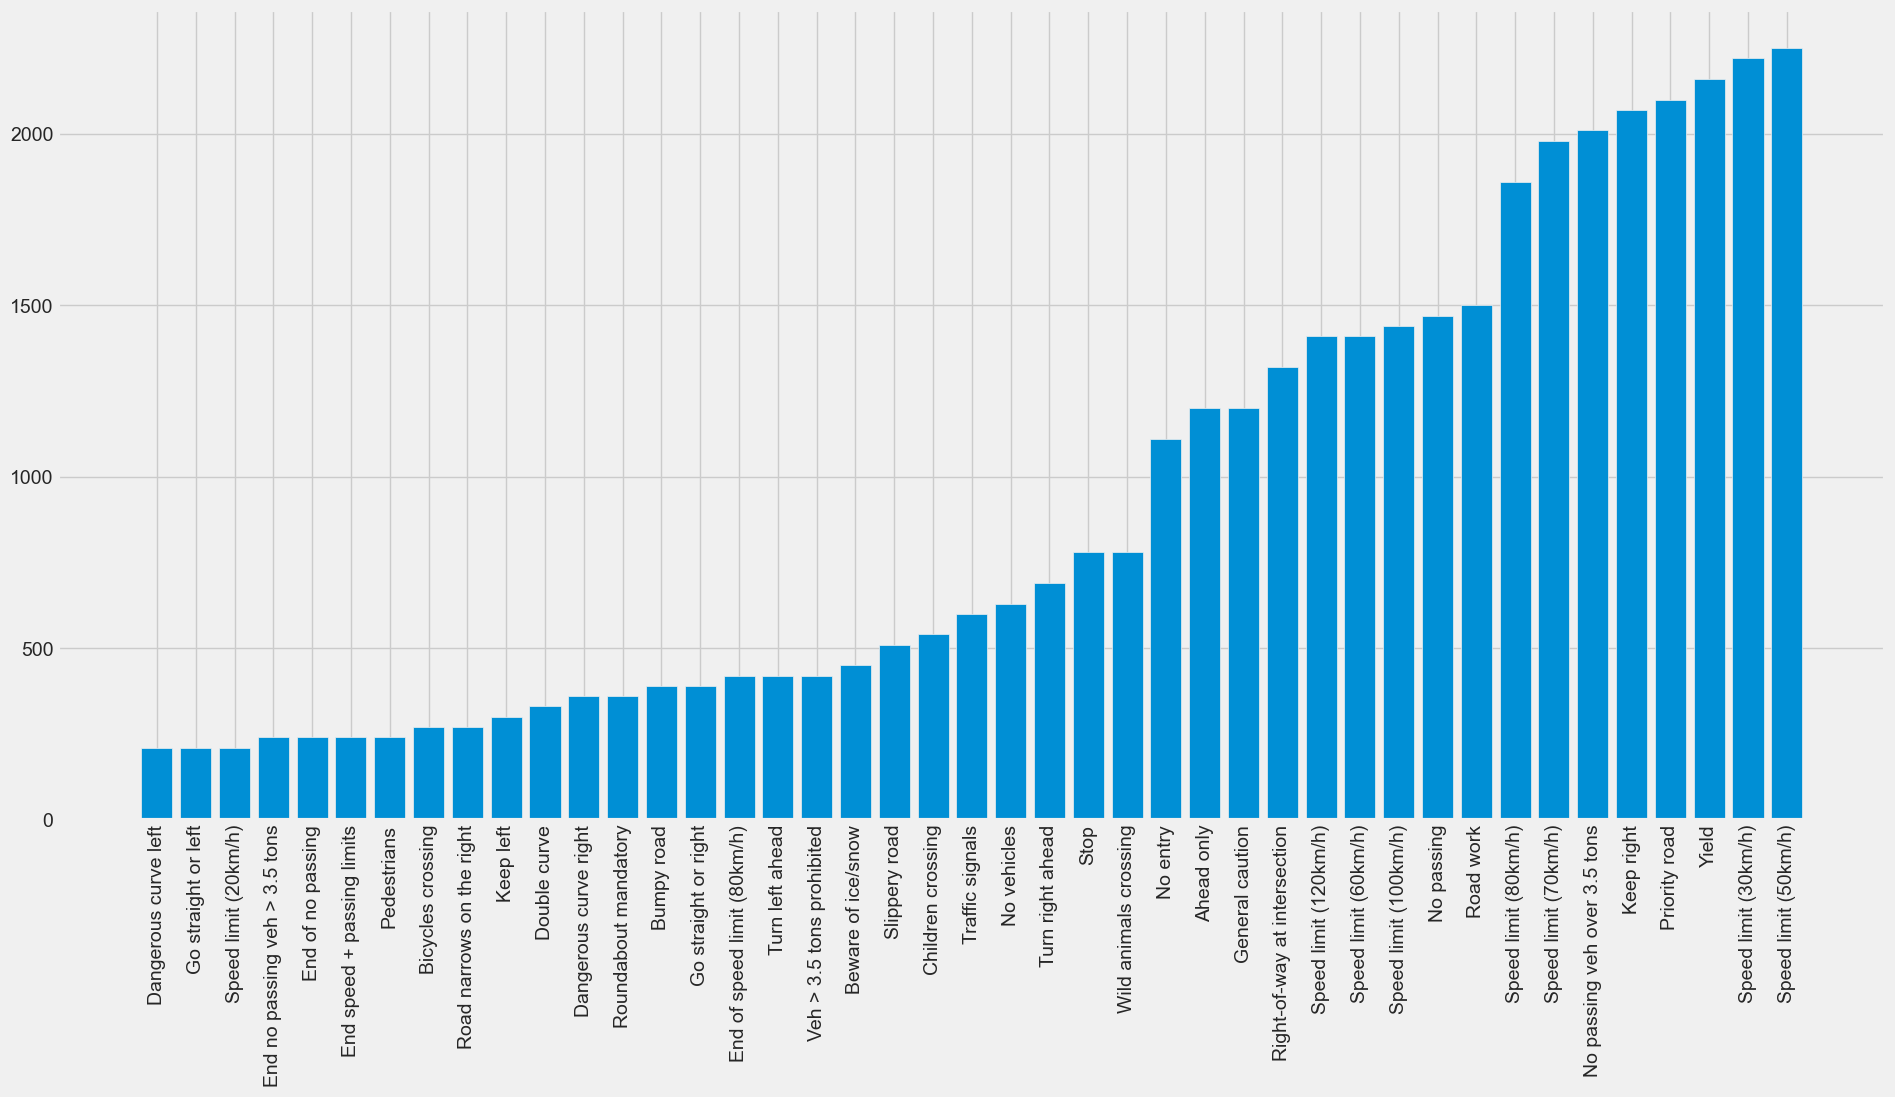

In [5]:
folders = os.listdir(train_path)

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_path + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])
    
# Sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

# Plotting the number of images in each class
plt.figure(figsize=(21,10))  
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

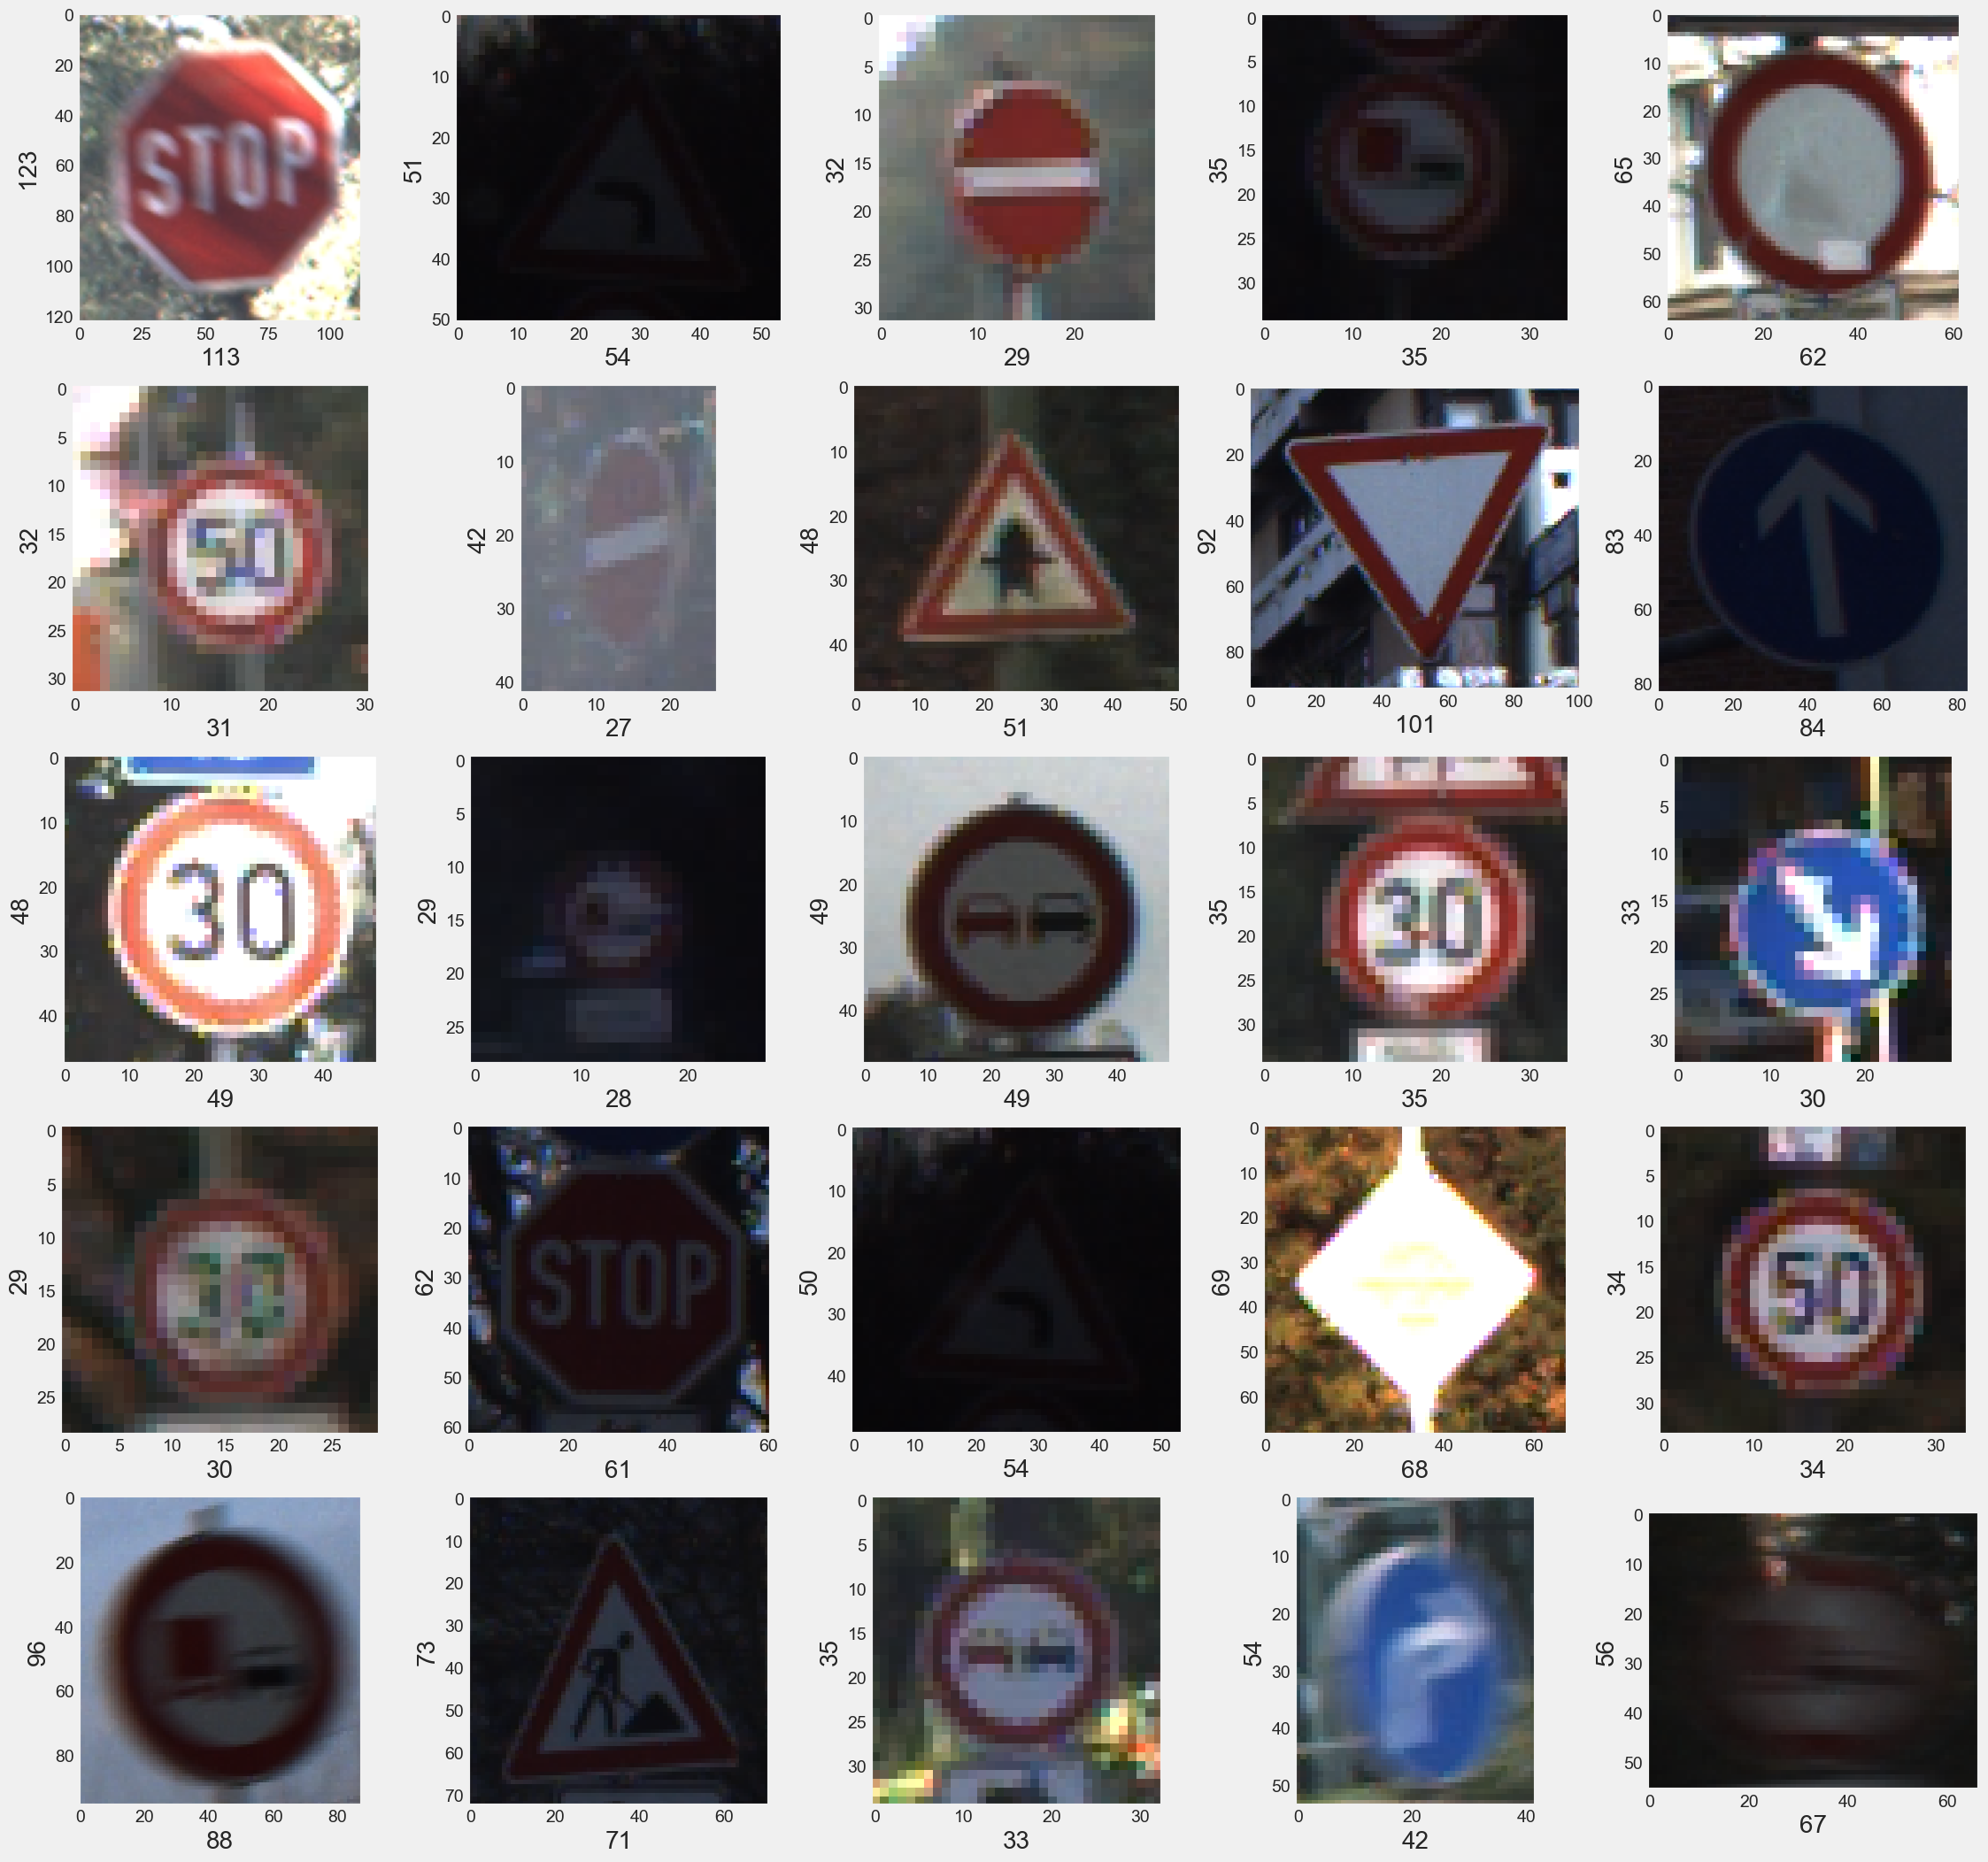

In [6]:
# Visualizing 25 random images from test data
import random
from matplotlib.image import imread

test = pd.read_csv(data_dir + '/Test.csv')
imgs = test["Path"].values

plt.figure(figsize=(25,25))

for i in range(1,26):
    plt.subplot(5,5,i)
    random_img_path = data_dir + '/' + random.choice(imgs)
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.grid(False)
    plt.xlabel(rand_img.shape[1], fontsize = 20)#width of image
    plt.ylabel(rand_img.shape[0], fontsize = 20)#height of image

## Collecting the Training Data

In [7]:
image_data = []
image_labels = []

for i in range(NUM_CATEGORIES):
    path = data_dir + '/Train/' + str(i)
    images = os.listdir(path)

    for img in images:
        try:
            image = cv2.imread(path + '/' + img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            image_data.append(np.array(resize_image))
            image_labels.append(i)
        except:
            print("Error in " + img)

# Changing the list to numpy array
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print(image_data.shape, image_labels.shape)

C:\Users\sreek\AppData\Local\Temp\ipykernel_16652\2417453468.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


(39209, 32, 32, 3) (39209,)


In [8]:
image_labels

array([ 0,  0,  0, ..., 42, 42, 42])

## Shuffling the training data

In [9]:
image_data.shape[0]

39209

In [10]:
shuffle_indexes=np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
shuffle_indexes
image_labels

array([ 0,  0,  0, ..., 42, 42, 42])

In [11]:
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes]
image_labels = image_labels[shuffle_indexes]

## Splitting the data into train and validation set

In [12]:
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.3, random_state=42, shuffle=True)

X_train = X_train/255 
X_val = X_val/255

print("X_train.shape", X_train.shape)
print("X_valid.shape", X_val.shape)
print("y_train.shape", y_train.shape)
print("y_valid.shape", y_val.shape)

X_train.shape (27446, 32, 32, 3)
X_valid.shape (11763, 32, 32, 3)
y_train.shape (27446,)
y_valid.shape (11763,)


## One hot encoding the labels

In [13]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print(y_train.shape)
print(y_val.shape)

(27446, 43)
(11763, 43)


## Making the model

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small

In [21]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models, optimizers



# Create base model
base_model = MobileNetV3Small(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet",   # pre-trained weights
    include_preprocessing=False
)

base_model.trainable = False   # Freeze backbone

# Add classification head
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CATEGORIES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\keras\src\applications\mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 655s 151us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 1, 1, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        24,811 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963,931 (3.68 MB)

 Trainable params: 24,811 (96.92 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [16]:
lr = 0.001
epochs = 30
# Define a LearningRateSchedule object
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=lr,
    decay_steps=10000,
    decay_rate=lr / (epochs * 0.5)
)
opt = Adam(learning_rate=lr_schedule )
#model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

## Augmenting the data and training the model

In [22]:
y_train.shape

(27446, 43)

In [23]:
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("mobilenetv2_best_stage1.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=epochs, validation_data=(X_val, y_val),callbacks=callbacks)

Epoch 1/30


C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.1945 - loss: 2.9557 - val_accuracy: 0.2979 - val_loss: 2.4682
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2787 - loss: 2.5208 - val_accuracy: 0.3329 - val_loss: 2.3074
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3141 - loss: 2.3882 - val_accuracy: 0.3611 - val_loss: 2.2065
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3281 - loss: 2.3245 - val_accuracy: 0.3753 - val_loss: 2.1427
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.3369 - loss: 2.2732 - val_accuracy: 0.3718 - val_loss: 2.1268
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.3425 - loss: 2.2486 - val_accuracy: 0.3778 - val_loss: 2.0915
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.3427 - loss: 2.2304 - val_accuracy: 0.3848 - val_loss: 2.0605
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.3510 - loss: 2.2139 - val_accurac

In [24]:
# ===============================================
# 4. Fine-Tuning – Unfreeze top layers
# ===============================================
base_model.trainable = True
# Freeze bottom layers (to keep low-level filters)
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_STAGE2 = 30
callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint("mobilenetv2_best_finetuned.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]


history_stage2 = model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=EPOCHS_STAGE2, validation_data=(X_val, y_val),callbacks=callbacks_ft)

Epoch 1/30


C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


858/858 ━━━━━━━━━━━━━━━━━━━━ 57s 53ms/step - accuracy: 0.0069 - loss: 46.7945 - val_accuracy: 0.0989 - val_loss: 6.9879
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.0125 - loss: 32.0969 - val_accuracy: 0.0340 - val_loss: 14.9741
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.0277 - loss: 17.7921 - val_accuracy: 0.0437 - val_loss: 12.9150
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 89s 103ms/step - accuracy: 0.0508 - loss: 11.1519 - val_accuracy: 0.0617 - val_loss: 9.5168
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 97s 50ms/step - accuracy: 0.0694 - loss: 8.4443 - val_accuracy: 0.0818 - val_loss: 7.4653
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.0816 - loss: 7.0469 - val_accuracy: 0.0987 - val_loss: 6.1997
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.0963 - loss: 6.1244 - val_accuracy: 0.1160 - val_loss: 5.3067
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.1112 - loss: 5.3069 - val_

KeyboardInterrupt: 

## Evaluating the model

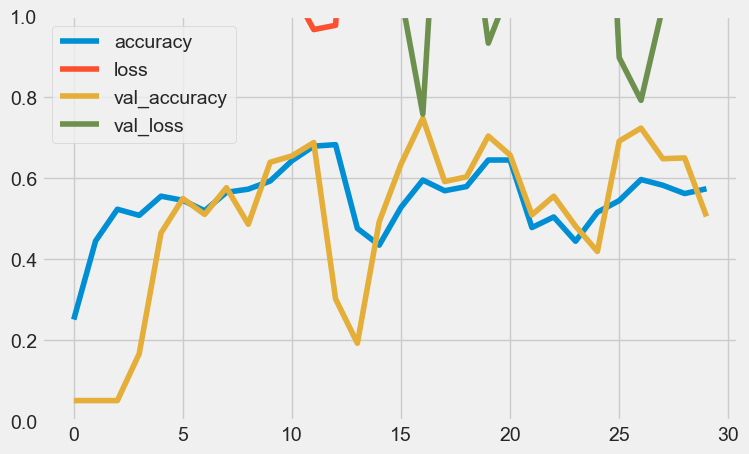

In [34]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Loading the test data and running the predictions

In [35]:
test = pd.read_csv(data_dir + '/Test.csv')

labels = test["ClassId"].values
imgs = test["Path"].values

data =[]

for img in imgs:
    try:
        image = cv2.imread(data_dir + '/' +img)
        image_fromarray = Image.fromarray(image, 'RGB')
        resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
        data.append(np.array(resize_image))
    except:
        print("Error in " + img)
X_test = np.array(data)
X_test = X_test/255

predictions = model.predict(X_test)

# 2. Use `np.argmax()` to get the class index with the highest probability
pred = np.argmax(predictions, axis=1)

#Accuracy with the test data
print('Test Data accuracy: ',accuracy_score(labels, pred)*100)

C:\Users\sreek\AppData\Local\Temp\ipykernel_28400\2991846419.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
Test Data accuracy:  45.65320665083135


## Visualizing the confusion matrix

In [36]:
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(labels, pred)

<Axes: >

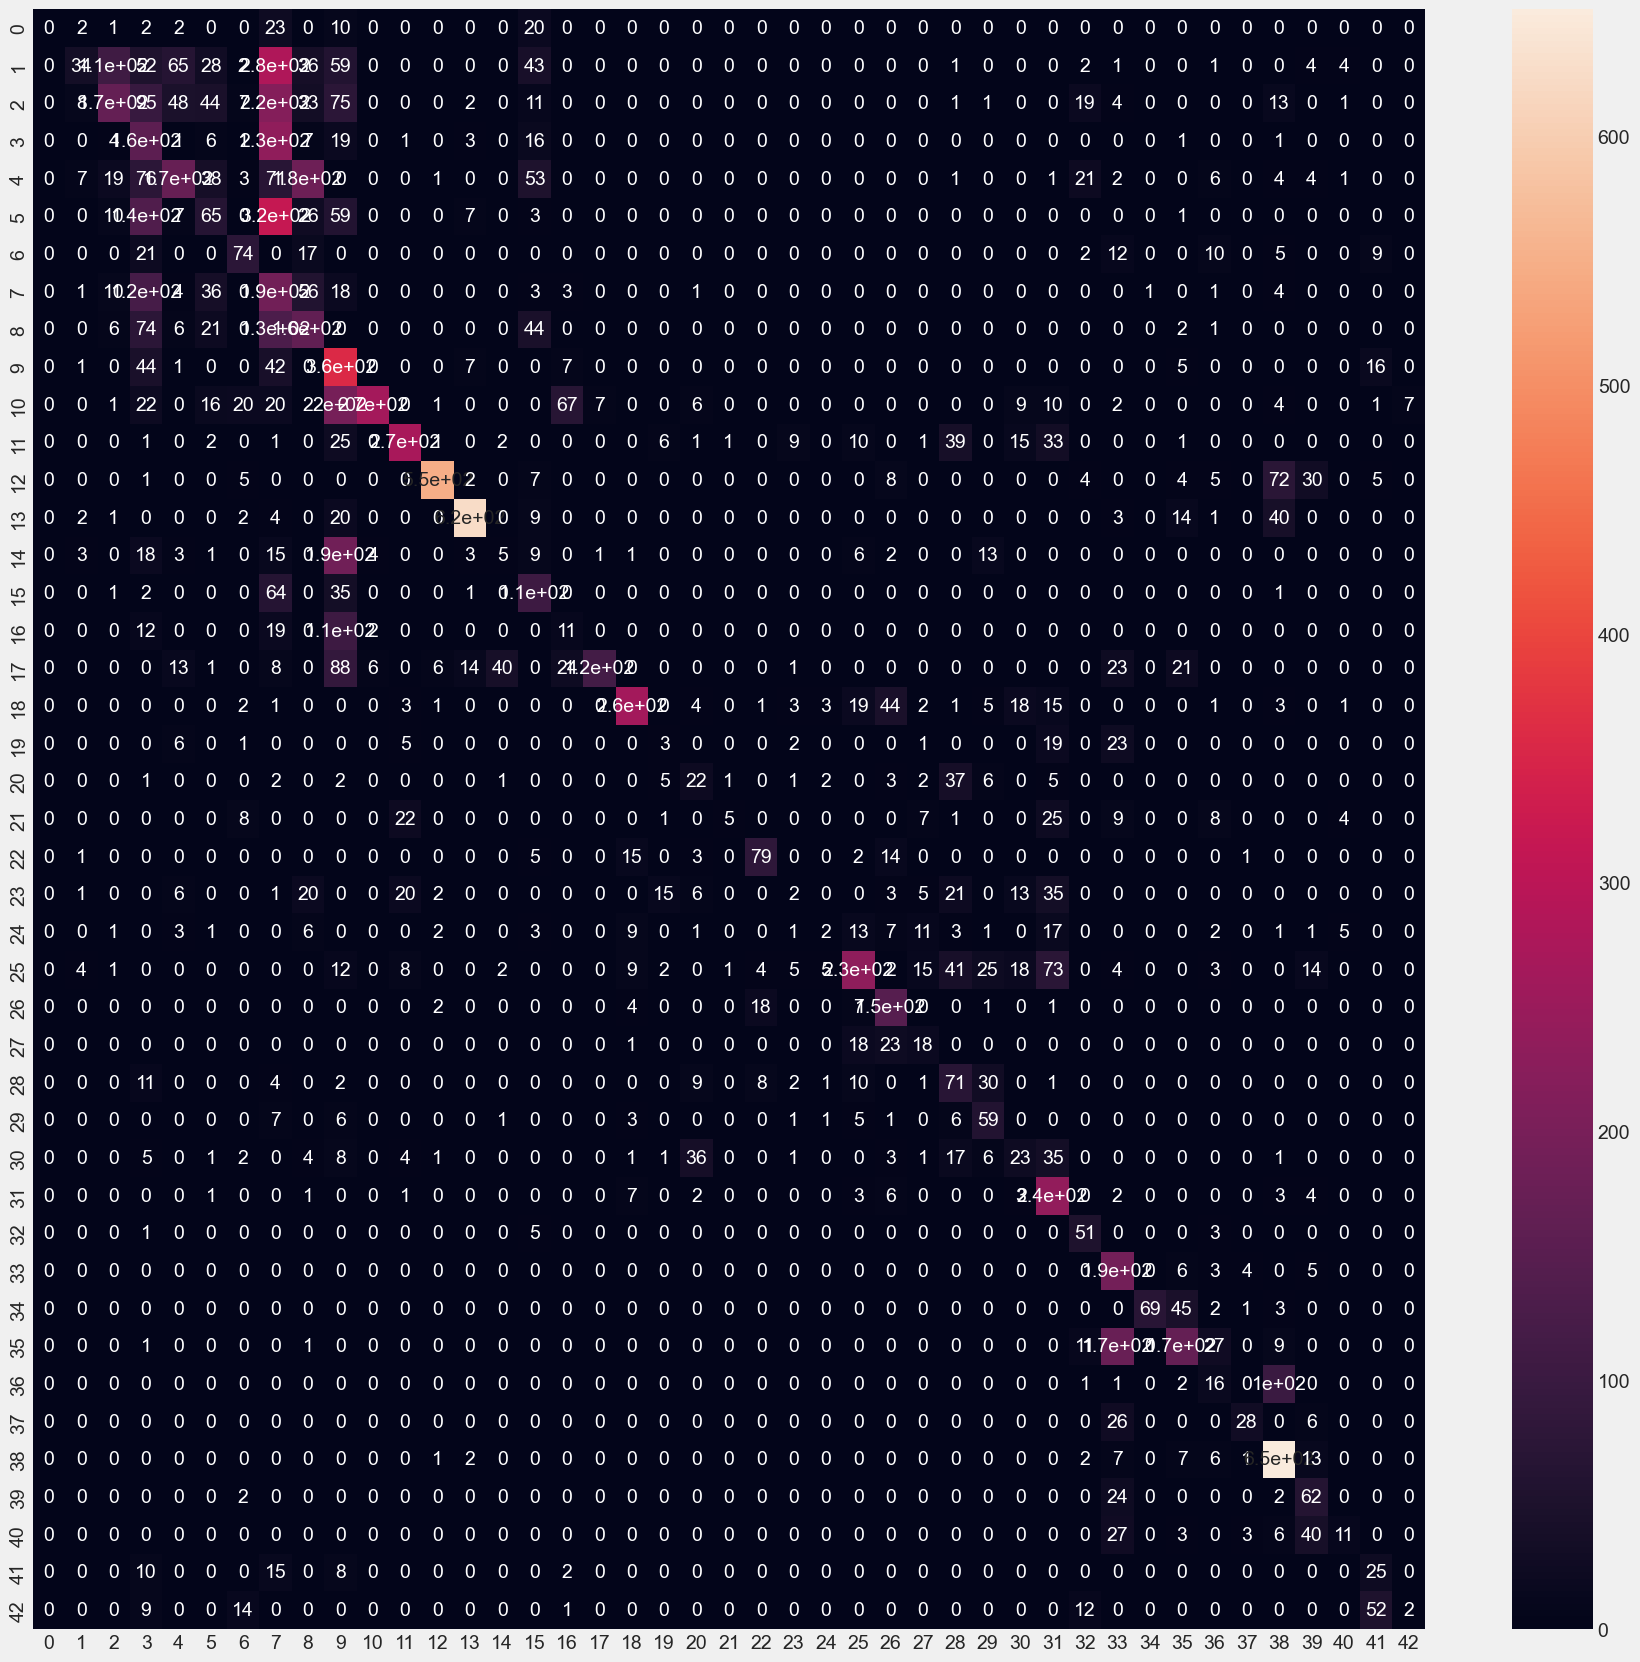

In [37]:
import seaborn as sns
df_cm = pd.DataFrame(cf, index = classes,  columns = classes)
plt.figure(figsize = (20,20))
sns.heatmap(df_cm, annot=True)

## Classification report

In [38]:
from sklearn.metrics import classification_report

print(classification_report(labels, pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.53      0.05      0.09       720
           2       0.51      0.23      0.31       750
           3       0.18      0.35      0.24       450
           4       0.51      0.26      0.34       660
           5       0.25      0.10      0.15       630
           6       0.52      0.49      0.51       150
           7       0.11      0.42      0.18       450
           8       0.30      0.36      0.33       450
           9       0.28      0.74      0.40       480
          10       0.96      0.40      0.57       660
          11       0.81      0.65      0.72       420
          12       0.97      0.79      0.87       690
          13       0.94      0.87      0.90       720
          14       0.10      0.02      0.03       270
          15       0.31      0.50      0.39       210
          16       0.10      0.07      0.08       150
          17       0.93    

C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

## Predictions on Test Data

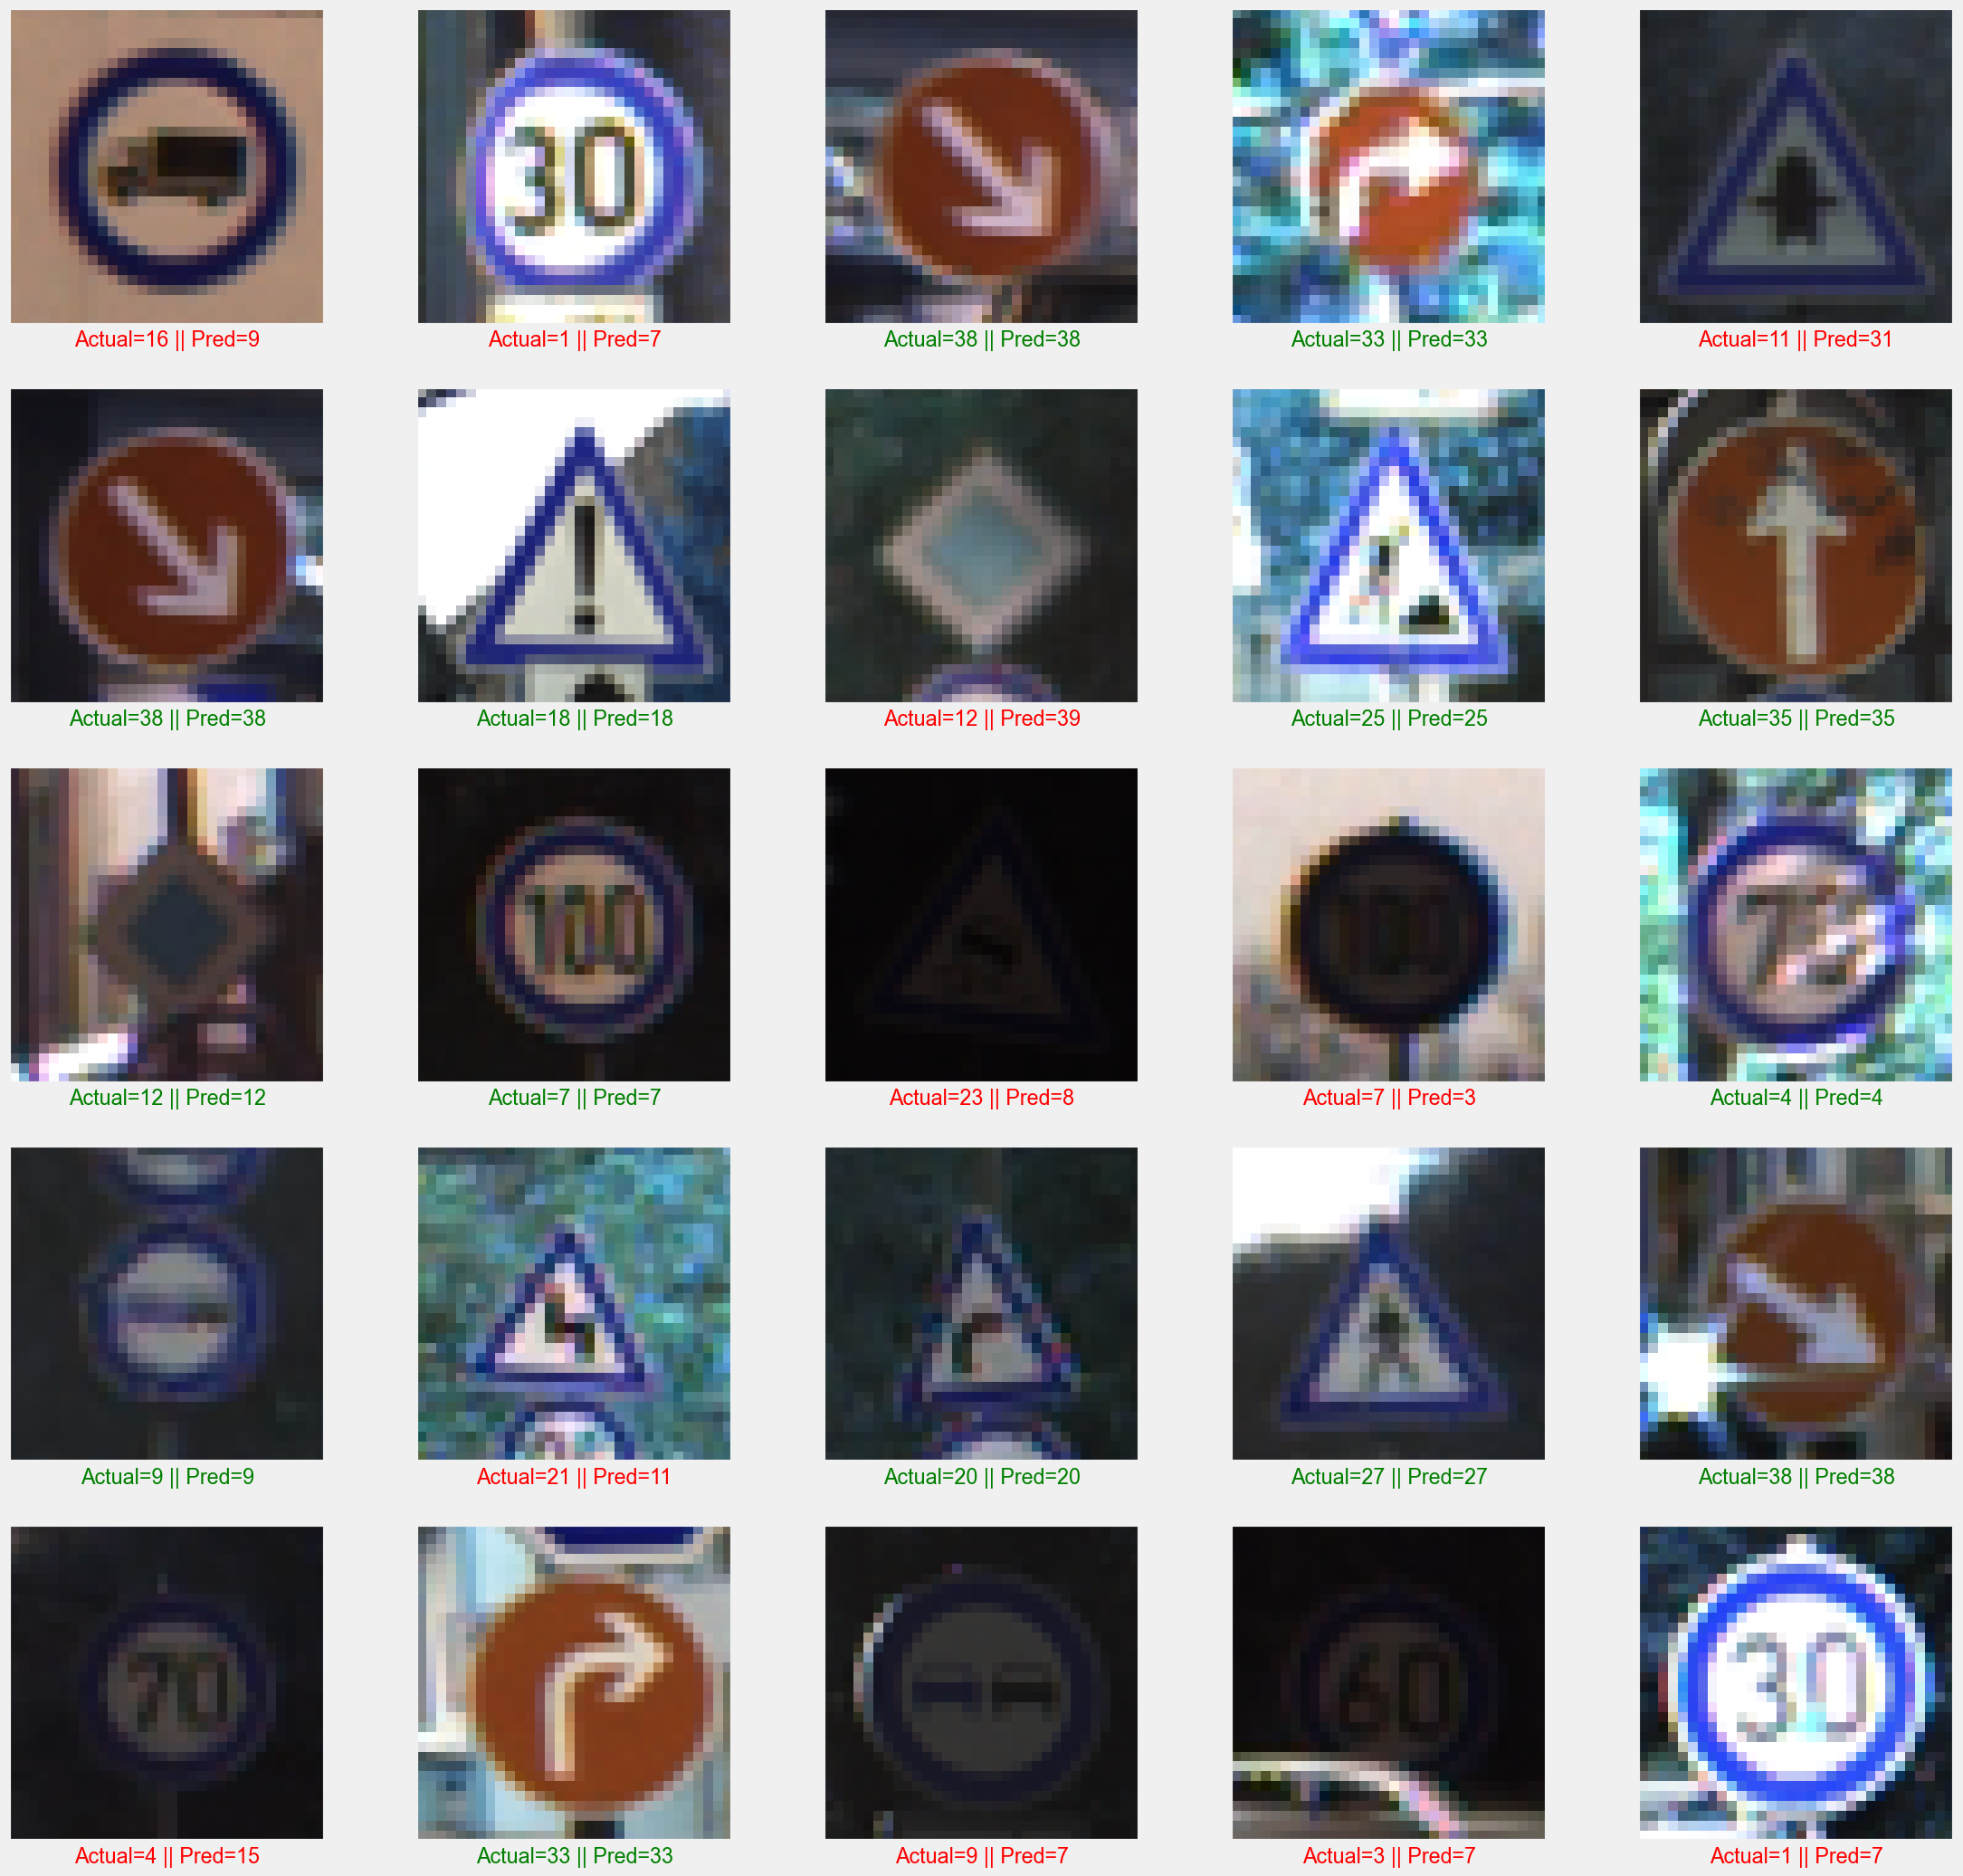

In [39]:
plt.figure(figsize = (25, 25))

start_index = 0
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    prediction = pred[start_index + i]
    actual = labels[start_index + i]
    col = 'g'
    if prediction != actual:
        col = 'r'
    plt.xlabel('Actual={} || Pred={}'.format(actual, prediction), color = col)
    plt.imshow(X_test[start_index + i])
plt.show()

In [40]:
import os
os.makedirs("./model", exist_ok=True)
model.save("./model/traffic_sign_custom_model3.keras")

print("\n✅ Model saved to 'model/traffic_sign_custom_model2.keras'")
print("You can now convert it to TensorFlow.js using:")
print("tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model/traffic_sign_mobilenetv2 web_model/")


✅ Model saved to 'model/traffic_sign_custom_model2.keras'
You can now convert it to TensorFlow.js using:
tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model/traffic_sign_mobilenetv2 web_model/
